# Introduction

This project is meant to serve as an in-depth analysis of the music artist Coldplay's discography. Coldplay are one of today's most popular bands in many countries around the world and have sold over 100 million albums. They have had influence on music through their reinventions of rock music into a more gentle and melodic style. Therefore, it is only sensible to consider what makes this world-renowned band who they are. 

To start, their evolution will be analyzed, including their gradual transition away from rock and towards pop-oriented music. Then, an important question will be investigated: what makes the band so popular? Various recorded features of their music will be considered. Finally, Coldplay have amassed a large discography throughout almost two decades (up to their ninth studio album) of music making. This music is fairly diverse and covers many different styles; does the data prove this?

The dataset used was taken from the following site: https://www.kaggle.com/datasets/faizalkarim/coldplay-albums-and-live-shows. It includes a comprehensive set of their music, including deluxe versions of their studio albums. The dataset originates from data collected by Spotify, which includes many different characteristics of each song, including the album, popularity, duration, tempo, and many others.

# Data Cleaning

First, the proper Python libraries will be imported, including pandas for data manipulation, matplotlib and seaborn for visualization, and numpy and scipy for various mathematical and statistical uses. The data is then imported from the csv file.

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

df = pd.read_csv("../data/raw/coldplay.csv")

df.sort_index(ascending=False)

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
231,Everything's Not Lost - Includes Hidden Track ...,436.440,2000-07-10,Parachutes,False,61,0.104000,0.3740,0.4560,0.000176,0.1970,-7.350,0.0368,135.643,4,0.0763
230,We Never Change,249.400,2000-07-10,Parachutes,False,65,0.535000,0.4330,0.2880,0.000169,0.1050,-10.801,0.0296,136.939,3,0.1310
229,High Speed,256.466,2000-07-10,Parachutes,False,65,0.396000,0.4950,0.5250,0.007360,0.0961,-9.342,0.0301,154.466,4,0.2490
228,Parachutes,46.200,2000-07-10,Parachutes,False,62,0.871000,0.5550,0.0845,0.000002,0.1380,-18.348,0.0518,137.001,4,0.3750
227,Trouble,273.426,2000-07-10,Parachutes,False,75,0.189000,0.5650,0.5460,0.001500,0.1700,-7.496,0.0314,139.757,4,0.1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Let Somebody Go,241.595,2021-10-15,Music Of The Spheres,False,76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4,0.1550
3,✨,53.033,2021-10-15,Music Of The Spheres,False,59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4,0.0380
2,Humankind,266.704,2021-10-15,Music Of The Spheres,False,68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4,0.2150
1,Higher Power,206.681,2021-10-15,Music Of The Spheres,False,71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4,0.4850


Before investigating the data, the datatypes are checked to see if they fit analysis needs.

In [163]:
df.dtypes

name                    str
duration            float64
release_date            str
album_name              str
explicit               bool
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
dtype: object

Two problems stand out. Firstly, time_signature should be a string and not a float, since time signatures are better interpreted as categories of numbers of beats rather than true numbers. It's also more informative to display the full time signature rather than just the number of beats, for example 3 -> 3/4.

In [164]:
df["time_signature"] = df["time_signature"].astype(str) + "/4"

df.dtypes

name                    str
duration            float64
release_date            str
album_name              str
explicit               bool
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
time_signature          str
valence             float64
dtype: object

In [165]:
df["time_signature"].head()

0    4/4
1    4/4
2    4/4
3    4/4
4    4/4
Name: time_signature, dtype: str

The other problem is that release_date should be a datetime to allow for plotting on line charts. 

In [166]:
df["release_date"] = pd.to_datetime(df["release_date"])
df.dtypes

name                           str
duration                   float64
release_date        datetime64[us]
album_name                     str
explicit                      bool
popularity                   int64
acousticness               float64
danceability               float64
energy                     float64
instrumentalness           float64
liveness                   float64
loudness                   float64
speechiness                float64
tempo                      float64
time_signature                 str
valence                    float64
dtype: object

Other issues are the scales of popularity and duration. Popularity has values on a scale between 0 and 100, but many other numeric features are between 0.0 and 1.0. To keep it consistent with the other features and allow for cleaner visualization, it will be rescaled to between 0.0 and 1.0. Additionally, duration is in seconds, but most people consider song duration in minutes.

In [167]:
df["popularity"] = df["popularity"] / 100
df["popularity"].describe()

df["duration"] = df["duration"] / 60

Next, possible whitespaces are checked to avoid duplicate results.

In [168]:
str_cols = df.select_dtypes(include=str).columns

df[str_cols] = df[str_cols].apply(lambda x: x.str.strip(), axis=0)

In [169]:
df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                      'Live in Buenos Aires',
                             'Love in Tokyo',
                     'A Head Full of Dreams',
        'A Head Full of Dreams Tour Edition',
                   'Ghost Stories Live 2014',
                             'Ghost Stories',
                                 'Live 2012',
                               'Mylo Xyloto',
             'LeftRightLeftRightLeft (Live)',
   'Viva La Vida (Prospekt's March Edition)',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
                                 'Live 2003',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 17, dtype: str

As shown above, the dataset contains live performances as well as the studio albums. Since live performances differ very little from the studio variants, they will be removed to avoid song duplicates. Note that their latest studio album, Moon Music, is not present in the dataset as the dataset was last updated 3 years ago.

In [170]:
df = df[df["album_name"].isin(['Music Of The Spheres',
                               'Everyday Life',
                               'A Head Full of Dreams',
                               'Ghost Stories',
                               'Mylo Xyloto',
                               'Viva La Vida or Death and All His Friends',
                               'X&Y',
                               'A Rush of Blood to the Head',
                               'Parachutes'])]

df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                     'A Head Full of Dreams',
                             'Ghost Stories',
                               'Mylo Xyloto',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 9, dtype: str

Now let's check for duplicates across all columns and specifically for the name column which shouldn't have duplicates.

In [171]:
print(df.duplicated().any())
print(df.duplicated(["name"]).any())

False
False


None can be found. Now let's check for possible missing values and empty strings.

In [172]:
print(df.isna().any(axis=1).any(axis=0))

False


In [173]:
df.apply(lambda x: x == "", axis=1).any(axis=0)

name                False
duration            False
release_date        False
album_name          False
explicit            False
popularity          False
acousticness        False
danceability        False
energy              False
instrumentalness    False
liveness            False
loudness            False
speechiness         False
tempo               False
time_signature      False
valence             False
dtype: bool

Again, none found. 

The indices no longer align with the length of the DataFrame, so it will be reindexed.

In [174]:
df.reset_index(drop=True, inplace=True)

df

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
0,🪐,0.886400,2021-10-15,Music Of The Spheres,False,0.62,0.887000,0.3260,0.3220,0.841000,0.1160,-20.192,0.0337,89.657,4/4,0.0651
1,Higher Power,3.444683,2021-10-15,Music Of The Spheres,False,0.71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4/4,0.4850
2,Humankind,4.445067,2021-10-15,Music Of The Spheres,False,0.68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4/4,0.2150
3,✨,0.883883,2021-10-15,Music Of The Spheres,False,0.59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4/4,0.0380
4,Let Somebody Go,4.026583,2021-10-15,Music Of The Spheres,False,0.76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4/4,0.1550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Trouble,4.557100,2000-07-10,Parachutes,False,0.75,0.189000,0.5650,0.5460,0.001500,0.1700,-7.496,0.0314,139.757,4/4,0.1950
108,Parachutes,0.770000,2000-07-10,Parachutes,False,0.62,0.871000,0.5550,0.0845,0.000002,0.1380,-18.348,0.0518,137.001,4/4,0.3750
109,High Speed,4.274433,2000-07-10,Parachutes,False,0.65,0.396000,0.4950,0.5250,0.007360,0.0961,-9.342,0.0301,154.466,4/4,0.2490
110,We Never Change,4.156667,2000-07-10,Parachutes,False,0.65,0.535000,0.4330,0.2880,0.000169,0.1050,-10.801,0.0296,136.939,3/4,0.1310


One may notice that there're strange emojis present in the name column. These are stylistic depictions of songs in the album Music of the Spheres.

In [175]:
df["name"].sort_values(ascending=False).head(10)

0            🪐
8            🌎
5           ❤️
3            ✨
10           ♾
25     بنی آدم
22         Èkó
72         Yes
106     Yellow
83         X&Y
Name: name, dtype: str

The actual names of the songs would be more helpful, so they will be individually replaced.

In [176]:
df.loc[[0, 8, 5, 3, 10, 25], "name"] = ["Music of the Spheres", "Music of the Spheres II", "Human Heart", "Alien Choir", "Infinity Sign", "Bani Adam"]

In [177]:
df[df["album_name"] == "Music Of The Spheres"]

,name,duration,release_date,album_name,explicit,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
0,Music of the Spheres,0.886400,2021-10-15,Music Of The Spheres,False,0.62,0.887000,0.3260,0.3220,0.841000,0.1160,-20.192,0.0337,89.657,4/4,0.0651
1,Higher Power,3.444683,2021-10-15,Music Of The Spheres,False,0.71,0.006430,0.5070,0.8320,0.000016,0.2290,-5.931,0.0425,177.894,4/4,0.4850
2,Humankind,4.445067,2021-10-15,Music Of The Spheres,False,0.68,0.000172,0.5750,0.8380,0.000103,0.4580,-6.498,0.0454,135.006,4/4,0.2150
3,Alien Choir,0.883883,2021-10-15,Music Of The Spheres,False,0.59,0.805000,0.0859,0.2890,0.990000,0.1410,-17.240,0.0359,166.784,4/4,0.0380
4,Let Somebody Go,4.026583,2021-10-15,Music Of The Spheres,False,0.76,0.193000,0.5920,0.3420,0.002450,0.1100,-8.930,0.0339,130.953,4/4,0.1550
5,Human Heart,3.149433,2021-10-15,Music Of The Spheres,False,0.65,0.970000,0.3480,0.0491,0.000186,0.0918,-15.431,0.0404,136.680,1/4,0.2320
6,People of The Pride,3.621100,2021-10-15,Music Of The Spheres,True,0.66,0.005810,0.4320,0.6130,0.015100,0.3120,-6.785,0.0349,136.362,4/4,0.0911
7,Biutyful,3.206567,2021-10-15,Music Of The Spheres,False,0.66,0.016800,0.6140,0.6800,0.000560,0.1180,-7.840,0.0425,153.937,4/4,0.3470
8,Music of the Spheres II,0.356467,2021-10-15,Music Of The Spheres,False,0.19,0.969000,0.1150,0.9070,0.981000,0.9800,-20.358,0.2230,189.885,3/4,0.0185
9,My Universe,3.769967,2021-10-15,Music Of The Spheres,False,0.84,0.011400,0.5730,0.7110,0.000000,0.3280,-6.268,0.0406,105.006,4/4,0.4700


Now the values of the columns will be checked for any invalid data. The following columns should only have values between 0.0 and 1.0.

In [178]:
columns = ['popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']

print(df[columns].min(), "\n")
print(df[columns].max())

popularity          0.000000
acousticness        0.000114
danceability        0.085900
energy              0.049100
instrumentalness    0.000000
liveness            0.035900
speechiness         0.024300
valence             0.018500
dtype: float64 

popularity          0.910
acousticness        0.970
danceability        0.738
energy              0.924
instrumentalness    0.990
liveness            0.980
speechiness         0.248
valence             0.802
dtype: float64


The other features are graphed to visuzlize their distributions and see if they're in order.

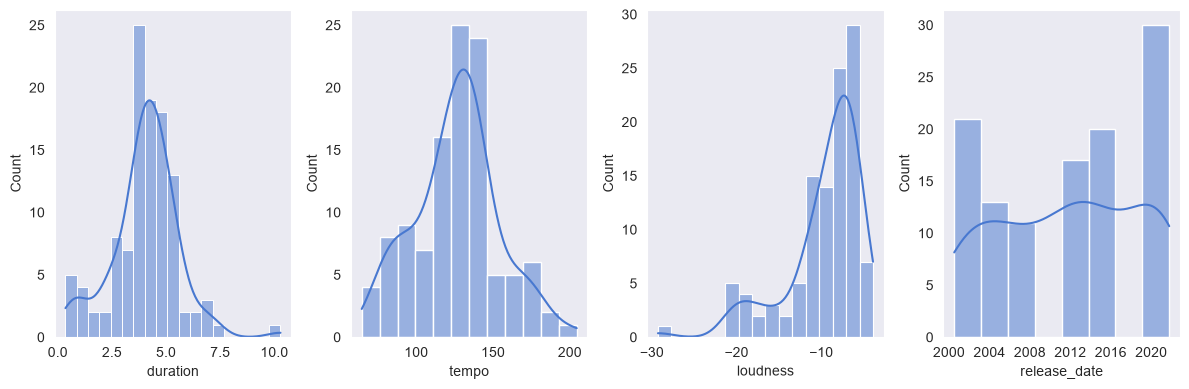

In [179]:
sns.set_style("dark")
sns.set_palette("muted")

fig, ax = plt.subplots(1, 4, figsize=(12, 4))

sns.histplot(x="duration", data=df, kde=True, ax=ax[0])
sns.histplot(x="tempo", data=df, kde=True, ax=ax[1])
sns.histplot(x="loudness", data=df, kde=True, ax=ax[2])
sns.histplot(x="release_date", data=df, kde=True, ax=ax[3])

plt.tight_layout()
plt.show()

Everything seems to fit expectations. Perhaps something initially suspicious is that there's a song around 600 seconds (ten minutes) long, however the song Coloratura is actually that long and thus it's not a mistake.

The fully cleaned data will be saved into a seperate file.

In [180]:
df.to_csv("../data/processed/coldplay_cleaned.csv", index=False)

# Coldplay's Evolution

Coldplay has amassed a diverse discography over the years spanning several subgenres of rock and pop. In particular, Coldplay is known for having transitioned from acoustic rock music in their earlier studio albums gradually into pop music in the modern-day. Therefore, I would expect their music to become less acoustic, more engertic, and greater in tempo.

Firstly, their first two albums are known as being acoustic rock, while they later transitioned into using more electronic instrumentation characteristic of pop.

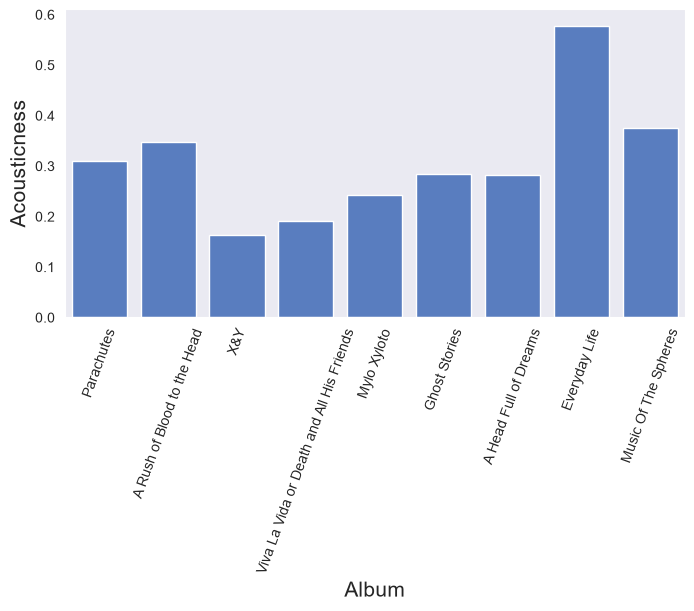

In [181]:
evolution_df = df.sort_values(by=["release_date"])

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="acousticness", data=evolution_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Acousticness", fontsize=15)
plt.xticks(rotation=70)

plt.show()

Indeed, the first two albums are more acoustic than later. Only with Everyday Life did they increase the acousticness of their music. 

Pop music is generally more energetic than acoustic rock, so perhaps the energy level increased.

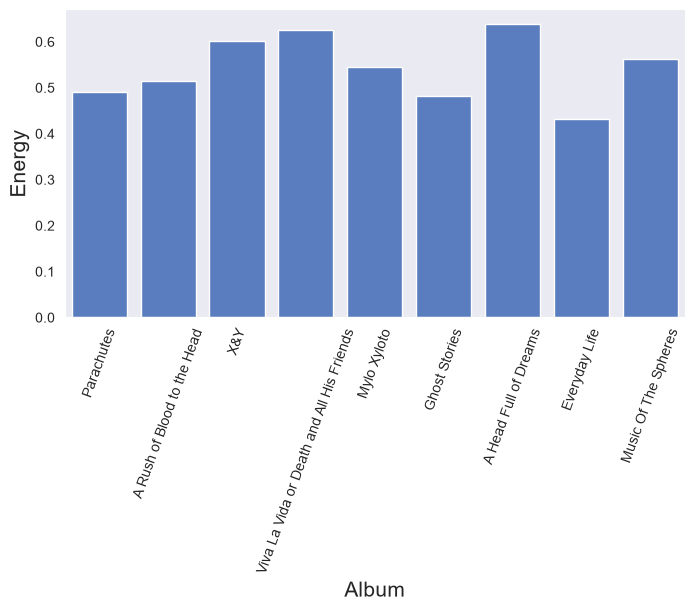

In [182]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="energy", data=evolution_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
plt.xticks(rotation=70)

plt.show()

This roughly lines up with expectations, with energy generally to trend upward. Exceptions such as Ghost Stories and Everyday Life do exist, as they were made with the intention of being more mellow. Of course, all albums have exceptions and wide ranges in energy, as shown below.

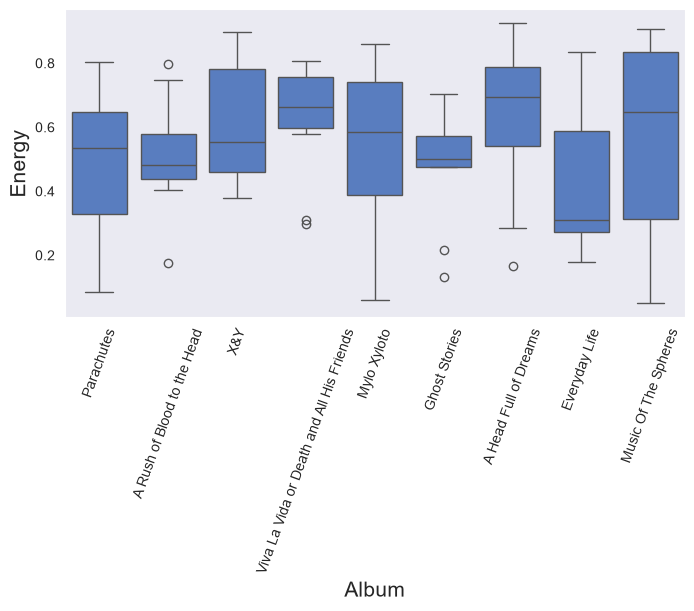

In [183]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x="album_name", y="energy", data=evolution_df)
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
plt.xticks(rotation=70)

plt.show()

Albums typically considered to be energetic, such as Viva La Vida or Death and All His Friends (Viva la Vida), have mellow tracks that act as outliers, such as Death And ALl His Friends. Similarily in A Rush of Blood to the Head, Clocks is significantly more energetic most of the other songs in the album. This shows that typcal album associations don't always hold for each indivdual song and that Coldplay has created great variety even within individual albums.

In [184]:
sub_df = evolution_df.query("album_name == 'Viva La Vida or Death and All His Friends' | album_name ==  'A Rush of Blood to the Head'")
sub_df[["album_name", "name", "energy"]]

,album_name,name,energy
91,A Rush of Blood to the Head,Politik,0.482
92,A Rush of Blood to the Head,In My Place,0.588
93,A Rush of Blood to the Head,God Put a Smile upon Your Face,0.556
94,A Rush of Blood to the Head,The Scientist,0.442
95,A Rush of Blood to the Head,Clocks,0.749
97,A Rush of Blood to the Head,Green Eyes,0.405
98,A Rush of Blood to the Head,Warning Sign,0.433
99,A Rush of Blood to the Head,A Whisper,0.797
100,A Rush of Blood to the Head,A Rush of Blood to the Head,0.472
101,A Rush of Blood to the Head,Amsterdam,0.176


Finally, one would assume that an increase in energy would mean faster music and therefore a greater tempo.

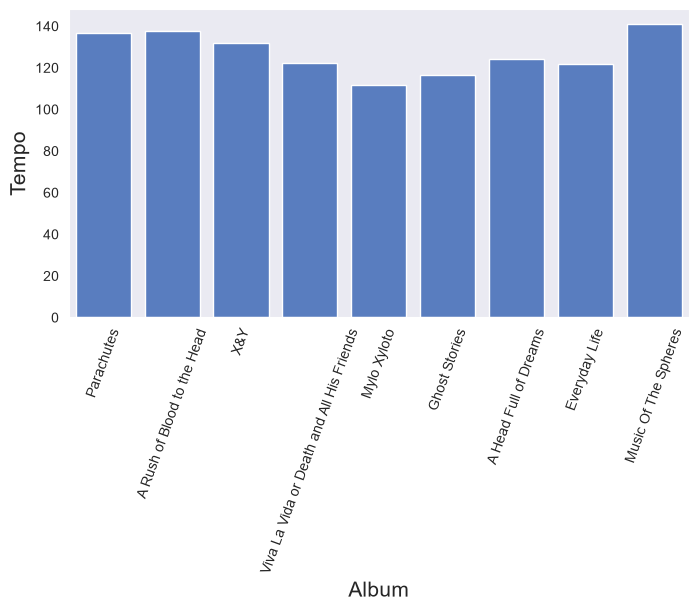

In [185]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x="album_name", y="tempo", data=evolution_df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Tempo", fontsize=15)
plt.xticks(rotation=70)

plt.show()

However the data seems to suggest the opposite. Tempo seemed to decrease with time, with the exception of Music Of The Spheres. Ironically, Parachutes and A Rush of Blood to the Head, some of their least energetic albums, have some of the fastest average tempos. This suggests that Spotify's energy metric captures aspects of a song beyond speed, such as loudness and production style. This can be seen when tempo and energy are compared directly.

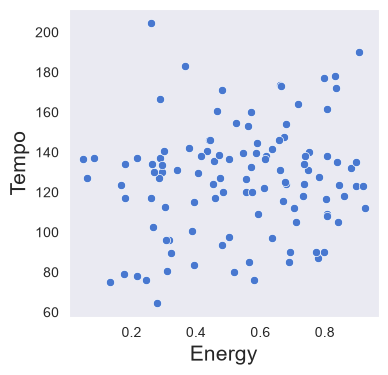

In [186]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(x="energy", y="tempo", data=evolution_df)
ax.set_xlabel("Energy", fontsize=15)
ax.set_ylabel("Tempo", fontsize=15)

plt.show()

There seems to be no significant relationship between the two, further proving that high energy in Coldplay's music isn't dependant on high tempo. Let's see if the increase in energy is due to denser instrumentation and generally being louder.

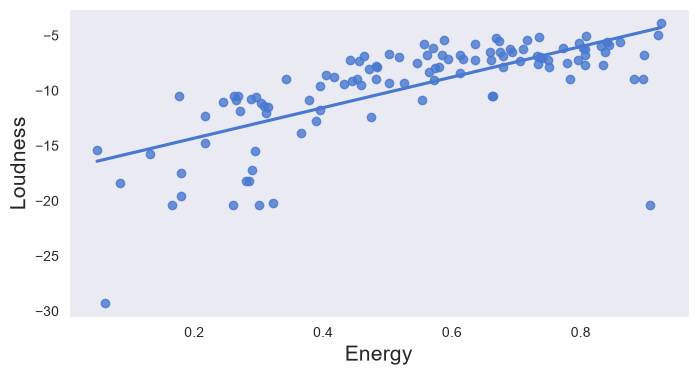

In [187]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.regplot(x="energy", y="loudness", data=evolution_df, ci=False)
ax.set_xlabel("Energy", fontsize=15)
ax.set_ylabel("Loudness", fontsize=15)

plt.show()

As expected, Coldplay's more energetic songs tend to be louder. This seems to explain the increase in energy, rather than tempo.

To conclude, many insights can be drawn regarding Coldplay's evolution. Generally speaking, their music became less acoustic, more energetic, less fast, and more loud with time. However, albums like Ghost Stories and Everyday Life defy some of these trends. Therefore, Coldplay's evolution can't be accurately summarized as simply following certain trends without acknowledging that their experimentation and genre-blending leads to much of their music defying certain assumptions.

# Coldplay Music Popularity

As seen, trends can be found in Coldplay's music through time. But an equally as interesting question: what makes their hit songs as popular as they are? Are there trends that can be uncovered? Spearmen correlation will be used to capture potential non-linear relationships.

In [188]:
df.corr(method="spearman", numeric_only=True)["popularity"]

duration            0.252075
explicit           -0.165986
popularity          1.000000
acousticness       -0.204117
danceability        0.297324
energy              0.166519
instrumentalness   -0.429745
liveness           -0.183960
loudness            0.340800
speechiness        -0.259655
tempo               0.143321
valence            -0.011878
Name: popularity, dtype: float64

Interestingly, there are no strong relationships with popularity, neither positive nor negative. This suggests that Coldplay song popularity is relatively unpredicteable. However, perhaps some non-monotonic relationships are indeed present that spearmen correlation can't capture well.

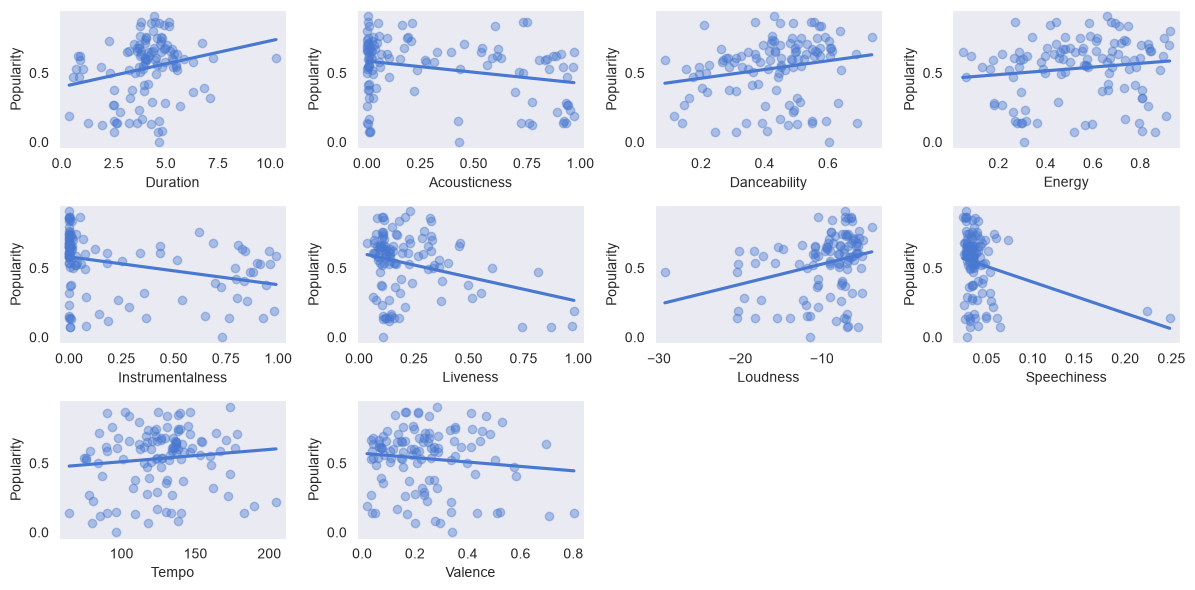

In [189]:
# Numeric columns excluding popularity itself
features = [col for col in df.select_dtypes(include='number').columns if col != 'popularity']

# Create a grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(12, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.regplot(x=feature, y='popularity', data=df, scatter_kws={"alpha": 0.4}, ci=False, ax=ax)
    ax.set_ylabel('Popularity')
    ax.set_xlabel(feature.capitalize())

# Remove any unused subplots
for ax in axes[len(features):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

This also doesn't appear to be the case. No clear relationships can be discovered from any of the plots. This suggests that popularity is influenced by a combination of factors beyond Spotify's audio descriptors, such as release strategy, cultural impact, and exposure. Additionally, it would be logical for a musically diverse artist like Coldplay to have many favored styles by fans, leading to no one set of characteristcs dominating.

But perhaps some of their studio albums are more popular than others. Many prefer their earlier albums over their modern music.

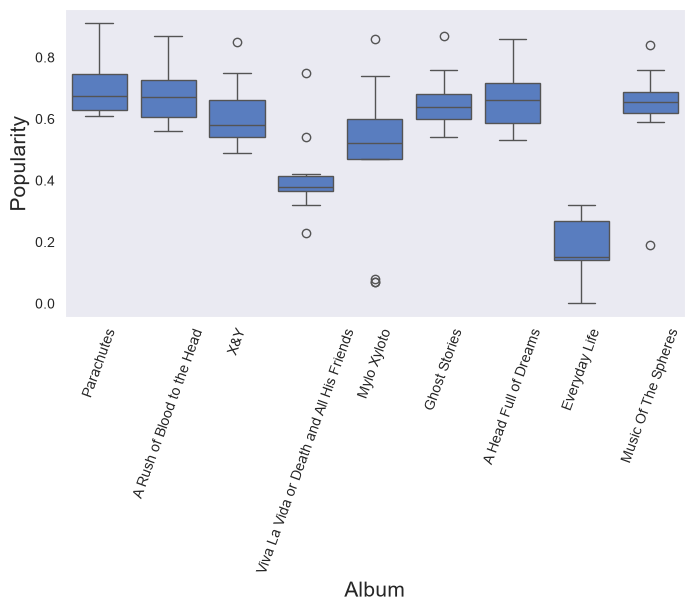

In [190]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x="album_name", y="popularity", data=evolution_df)
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Popularity", fontsize=15)
plt.xticks(rotation=70)

plt.show()

Some interesting insights can be drawn:
* Their first two albums are indeed their most popular ones, albeit not by a significant amount.
* Some albums, especially Everyday Life, have significantly lower median scores than the others. This fits many unpopular opinions listeners have regarding their eighth album.
* Many strong outliers exist. For example, despite Viva La Vida ranking lower than the others overall, two songs strongly outperform the rest of the album. This is sometimes the case in music; one or a few songs can be significantly more popular than the rest of the album.

All of these results underscore how diverse Coldplay's music is and how many styles they have tried over the years. No one style seems to draw fans' attention more than others and predicting popularity is clearly more complicated than simply anlyzing music's audio characteristics.

# Feature Distributions and Relartionships

I have been mentioning Coldplay's diversity, both in the context of their evolution through time and of the popularity of their music. But just how diverse does Coldplay get? Which characteristics are more varied and which tend to be more consistent? What relationships might some have with one another?

There are many key metrics to analyze. Firstly, the feature just analyzed: popularity. Their albums have strong differences in popularity, but what about their indiviudal songs?

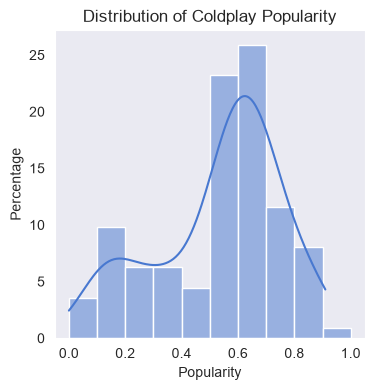

In [191]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="popularity", stat="percent", bins=10, binrange=(0.0, 1.0), kde=True, data=df)
ax.set_xlabel("Popularity")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Popularity")

plt.show()

Coldplay seems to be reasonably popular, with around 50% of their music being between 0.5 and 0.7. A good portion of their music is between 0.1 and 0.4, however. This is likely made up in majority by those less popular albums found before.

Coldplay is also known for having generally happy and positive music, and usually don't stray into sad melodies. One would therefore expect the majority of their music to sit around high valence values.

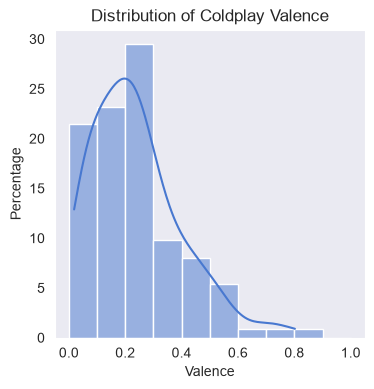

In [192]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="valence", stat="percent", bins=10, binrange=(0.0, 1.0), kde=True, data=df)
ax.set_xlabel("Valence")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Valence")

plt.show()

Very strangely, the exact opposite seems to be the case. This doesn't appear to make sense, however Spotify's valence characteristic could be a complex measure describing a variety of features of the music. Some attributes included might be:
* major vs. minor tonality
* harmony
* chord progressions
* timbre
* melodic contour
* rhythmic characteristics

It's especially complicated with Coldplay, an artist that has experimented with many styles, often does genre-mixing, and can have emotionally complicated lyrics. That said, it's worth looking into possible correlations with the other features.

In [193]:
df.corr(method="spearman", numeric_only=True)["valence"]

duration           -0.195676
explicit            0.051342
popularity         -0.011878
acousticness       -0.211082
danceability        0.466918
energy              0.277823
instrumentalness   -0.138679
liveness            0.091043
loudness            0.210022
speechiness         0.187370
tempo              -0.194543
valence             1.000000
Name: valence, dtype: float64

Similarly to popularity, no strong relationships exist with valence. However, there is a moderate positive relationship with danceability.

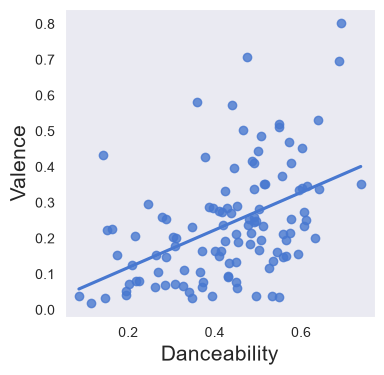

In [194]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.regplot(x="danceability", y="valence", data=df, ci=False)
ax.set_xlabel("Danceability", fontsize=15)
ax.set_ylabel("Valence", fontsize=15)

plt.show()

This makes sense, as usually the kind of music that people like to dance to is upbeat.

Since Coldplay has experimented with different genres, one would expect there to be wide variety in the speed and intensity of their music. That warrents investigating danceability, loudness, energy, and tempo.

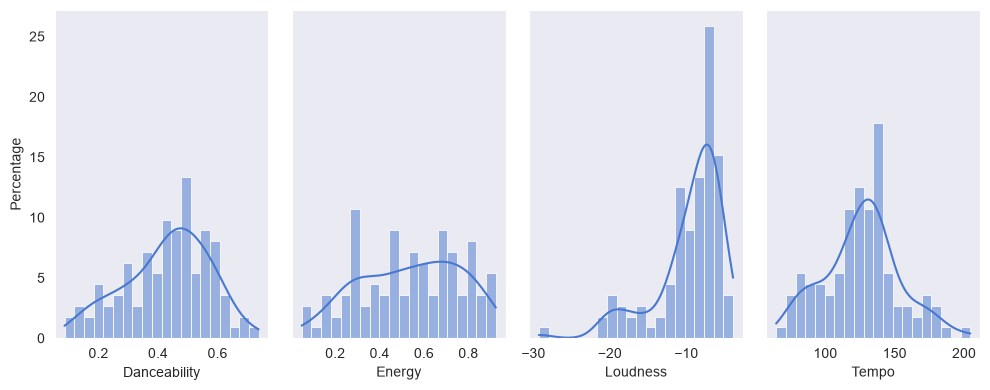

In [202]:
fig, axes = plt.subplots(1, 4, figsize=(10, 4), sharey=True)
axes = axes.flatten()

features = ["danceability", "energy", "loudness", "tempo"]

for feature, ax in zip(features, axes):
    sns.histplot(x=feature, stat="percent", data=df, bins=20, kde=True, ax=ax)
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Percentage")

plt.tight_layout()
plt.show()

In [ ]:
features = ["danceability", "energy", "loudness", "tempo"]

df[features].corr(method="spearman")

,danceability,energy,loudness,tempo
danceability,1.000000,0.124770,0.137234,-0.113815
energy,0.124770,1.000000,0.753249,0.096377
loudness,0.137234,0.753249,1.000000,0.070446
tempo,-0.113815,0.096377,0.070446,1.000000


This is roughly the case, as, indeed, the values cover a wide range. However, there are some centers for each feature: danceability around 0.5, loudness around -8 decibels, and tempo around 130 beats per minute. Overall, this suggest that their music tends to be relatively loud (typical decibel values are between -60 and 0) and fast (130 is characterized as allegro, or fast). However, energy and danceability show more variety. This would suggest that there could be many loud and fast songs that aren't necessarily energetic or suitable for dancing. And, as expected, no strong relationships are present with danceability and the others, nor with energy and the others. This implies that it's possible for an energetic song to be fast or slow, for example. As shown previously in the discussion on Coldplay's evolution, energy and loudness are strongly correlated and energy and tempo aren't. Interestingly though, there's no strong relationship between tempo and loudness. One would expect loud music to be faster, but this is apparently not the case. This fits songs that are loud, but not fast, such as A Sky Full of Stars.

Lastly, what is the average duration of Coldplay's music? Coldplay tends to make longer songs over 4 minutes long, so likely the peak will be there.

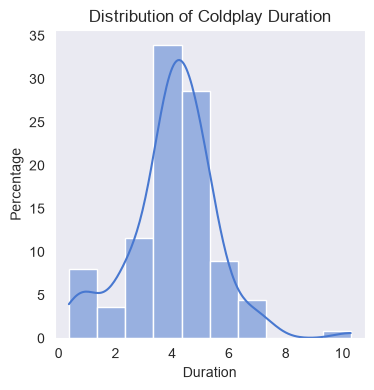

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="duration", stat="percent", bins=10, kde=True, data=df)
ax.set_xlabel("Duration")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Duration")

plt.show()

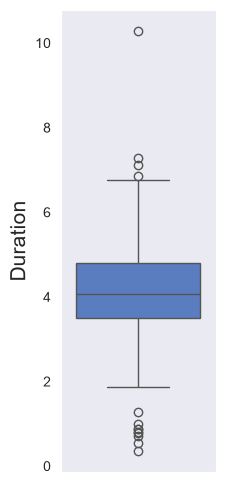

In [ ]:
fig, ax = plt.subplots(figsize=(2, 6))

sns.boxplot(y="duration", data=df)
ax.set_ylabel("Duration", fontsize=15)

plt.show()

As expected, the majority of Coldplay music is around 4 minutes long. Likely around two thirds of their whole discography. This can be confirmed below.

In [ ]:
round(len(df.query("duration >= 3 & duration <= 5")) / len(df) * 100, 2)

61.61

Indeed, over 60% of the soundtrack is within a minute from 4 minutes long. Additionally, there are many outliers, including by far the longest song in their discography: Coloratura from Music Of The Spheres.

This analysis underscores how varied, yet also consistent Coldplay can be. Their popularity is usually around 0.6, their loudness around -8 db, their tempo around 130 bpm, and their duration around 4 minutes. However, energy and danceability are more varied.

# Conclusions

Many insights can be drawn from this analysis and which answer our previous questions:
-How did Coldplay evolve? Their music gradually drifted away from acoustic rock and towards pop and this shows in the features of their music. -What charcterizes their popular and unpopular music? Interestingly, nothing in particular other than their early albums being slightly more popular on average.
-How diverse is Coldplay? Some features are relatively diverse, such as energy, while others are fairly consistent, such as song duration.

However, perhaps the single most important insight that can be gathered is that Coldplay don't perfectly fit any of these trends. Coldplay are a band that don't try to settle into one particular style or one particular feature of their music. Prominent exceptions and outliers exist for all of these insights, whether it be Everyday Life being highly acoustic despite being a later album, or whether it be tempo generally being high, yet slow songs such as Oceans from Ghost Stories existing as well. Coldplay cannot be grouped under one simple category or given one catch-all label, and they likely don't want to be either. After all, that's what truly makes Coldplay Coldplay.